# Heart Disease Prediction — Feature Engineering & Data Preprocessing
**AnalystLab Africa | Data Science Internship — Week 2**

Author: Junior Data Scientist, AnalystLab Africa Consulting

This notebook picks up where Week 1 left off. Back then it was all about looking
at data and telling a story with it. This week the goal is different: I'm not
trying to *explain* anything yet, I'm trying to get this dataset into a shape
that a machine learning model could actually be trained on. That means cleaning
it properly, encoding the text columns, scaling the numeric ones, dealing with
outliers, and picking which features are actually worth keeping.

**Dataset:** Heart Failure Prediction Dataset (Kaggle, via fedesoriano)
**Goal:** predict `HeartDisease` (1 = patient has heart disease, 0 = they don't)

## 1. Setup

Importing everything I'll need up front so I'm not scrolling back and forth
adding imports halfway through.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

# a few settings so the notebook looks clean instead of default-matplotlib-ugly
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded, let's get into it.")

Libraries loaded, let's get into it.


## 2. Load the Dataset & First Look

Loading the raw CSV and eyeballing the first 10 rows before doing anything else.
I always do this first — you catch weird stuff (misaligned columns, odd
encodings) just by looking before you even run a single `.describe()`.

In [2]:
df = pd.read_csv('heart.csv')
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


## 3. Dataset Structure

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print()
df.info()

Rows: 918
Columns: 12

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


918 patient records, 12 columns. 11 of those are potential predictors and the
12th (`HeartDisease`) is the thing we're trying to predict.

### 3.1 Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary

,missing_count,missing_pct
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0


Pandas is telling me there are zero nulls anywhere. Nice — but I've seen this
dataset before (or ones like it), and I know from experience that "no nulls"
doesn't always mean "no missing data." Sometimes missing values get coded as
0 instead of being left blank, especially for measurements that could never
actually be zero in a living person. I'll check for that properly in the
cleaning section instead of taking `isnull()` at face value.

### 3.2 Duplicate Records

In [5]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

Duplicate rows: 0


No exact duplicate rows. One less thing to worry about.

### 3.3 Data Types

In [6]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

### 3.4 Summary Statistics

In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


This is where the "no missing values" claim starts to look shaky. Look at
`RestingBP` — the minimum is 0. A resting blood pressure of 0 isn't a real
medical reading, that's a person who would be dead, not a patient in a
dataset. Same logic applies to `Cholesterol` below.

In [8]:
df.describe(include='object' if 'object' in df.dtypes.values else 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2


### 3.5 Categorical Columns — Unique Values

In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"{col}: {df[col].unique().tolist()}")

Sex: ['M', 'F']
ChestPainType: ['ATA', 'NAP', 'ASY', 'TA']
RestingECG: ['Normal', 'ST', 'LVH']
ExerciseAngina: ['N', 'Y']
ST_Slope: ['Up', 'Flat', 'Down']


/tmp/ipykernel_492/2168342841.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


### 3.6 Target Variable Balance

In [10]:
target_counts = df['HeartDisease'].value_counts()
target_pct = df['HeartDisease'].value_counts(normalize=True).mul(100).round(1)
print(target_counts)
print()
print(target_pct)

HeartDisease
1    508
0    410
Name: count, dtype: int64

HeartDisease
1    55.3
0    44.7
Name: proportion, dtype: float64


55.3% of the patients in this dataset have heart disease, 44.7% don't. That's
a pretty balanced target, honestly — much less lopsided than the attrition
data I worked with in Week 1. That's good news for later, because it means I
probably won't need to lean as hard on techniques like SMOTE or class
weighting when a model eventually gets trained on this.

### 3.7 The Hidden Missing Values

This is the part I flagged above. Let's actually count how many rows have a
biologically impossible zero in `RestingBP` and `Cholesterol`.

In [11]:
zero_bp = (df['RestingBP'] == 0).sum()
zero_chol = (df['Cholesterol'] == 0).sum()
print(f"RestingBP == 0: {zero_bp} row(s)")
print(f"Cholesterol == 0: {zero_chol} row(s) — that's {zero_chol/len(df)*100:.1f}% of the dataset")

RestingBP == 0: 1 row(s)
Cholesterol == 0: 172 row(s) — that's 18.7% of the dataset


So there's 1 patient with a resting blood pressure of 0, and 172 patients
(nearly 1 in 5!) with a cholesterol reading of 0. Those aren't real values,
they're missing data that someone encoded as 0 instead of leaving blank —
probably because the original source system didn't allow nulls in a numeric
field. I'm treating both of these as missing values, not as genuine
measurements, and I'll handle them properly in Section 5.

## 4. Initial Visual Exploration

Before I start changing anything, I want to actually *see* the data. A table
of summary statistics only tells you so much — a picture tells you a lot
faster whether something's skewed, whether there are wild outliers, or
whether a category is basically empty.

### Visualization 1 — Age Distribution (Histogram)

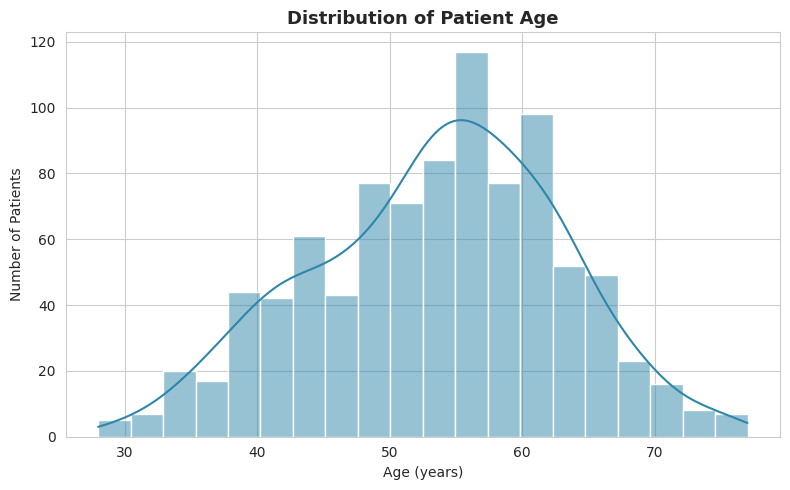

In [12]:
fig, ax = plt.subplots()
sns.histplot(df['Age'], bins=20, kde=True, color='#2E86AB', ax=ax)
ax.set_title('Distribution of Patient Age', fontsize=13, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('viz_01_age_hist.png', dpi=110)
plt.show()

Age is roughly bell-shaped, centred around the late 50s, with most patients
falling somewhere between 45 and 65. Makes sense — heart disease risk isn't
usually something clinicians are screening for heavily in very young
patients, so it tracks that this dataset skews toward middle-aged and older
people.

### Visualization 2 — Cholesterol Distribution (Histogram, before cleaning)

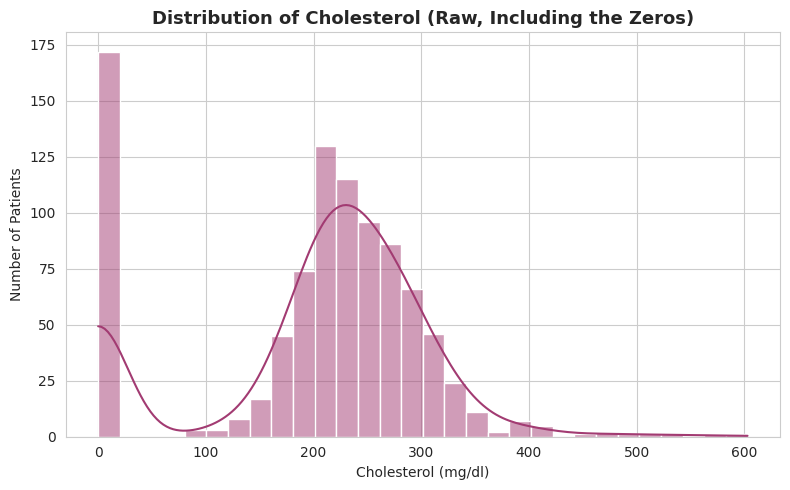

In [13]:
fig, ax = plt.subplots()
sns.histplot(df['Cholesterol'], bins=30, kde=True, color='#A23B72', ax=ax)
ax.set_title('Distribution of Cholesterol (Raw, Including the Zeros)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cholesterol (mg/dl)')
ax.set_ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('viz_02_chol_hist_raw.png', dpi=110)
plt.show()

See that tall spike sitting all the way at 0? That's the 172 disguised
missing values I found earlier. If I left this as-is and fed it into a
model, the model would think a big chunk of patients have literally no
cholesterol in their blood, which is nonsense and would badly distort
anything trained on this column. This chart alone is a good justification
for treating those zeros as missing.

### Visualization 3 — Heart Disease Count by Sex (Count Plot)

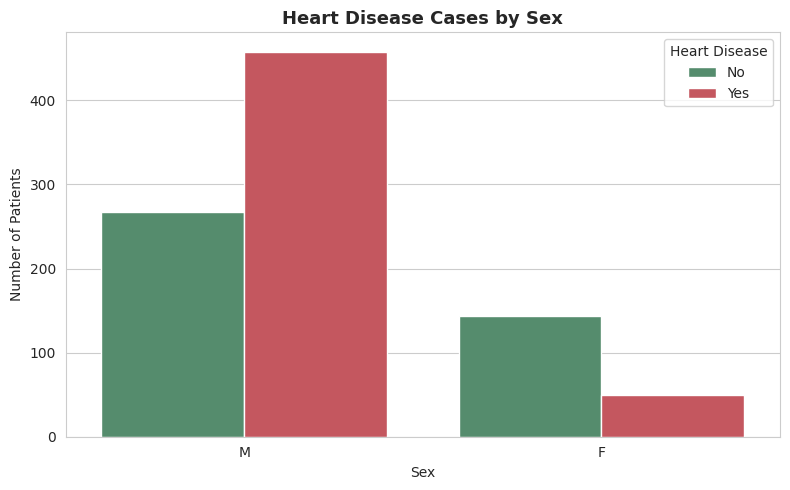

In [14]:
fig, ax = plt.subplots()
sns.countplot(data=df, x='Sex', hue='HeartDisease', palette=['#4C956C', '#D64550'], ax=ax)
ax.set_title('Heart Disease Cases by Sex', fontsize=13, fontweight='bold')
ax.set_xlabel('Sex')
ax.set_ylabel('Number of Patients')
ax.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('viz_03_sex_countplot.png', dpi=110)
plt.show()

There are way more male patients than female patients in this dataset
overall, and the proportion with heart disease looks noticeably higher among
the men too. I'm not going to overclaim anything clinical from this (I'm not
a doctor and this is a fairly small sample), but it does suggest `Sex` is
worth keeping around as a feature.

### Visualization 4 — Chest Pain Type vs Heart Disease (Bar Chart)

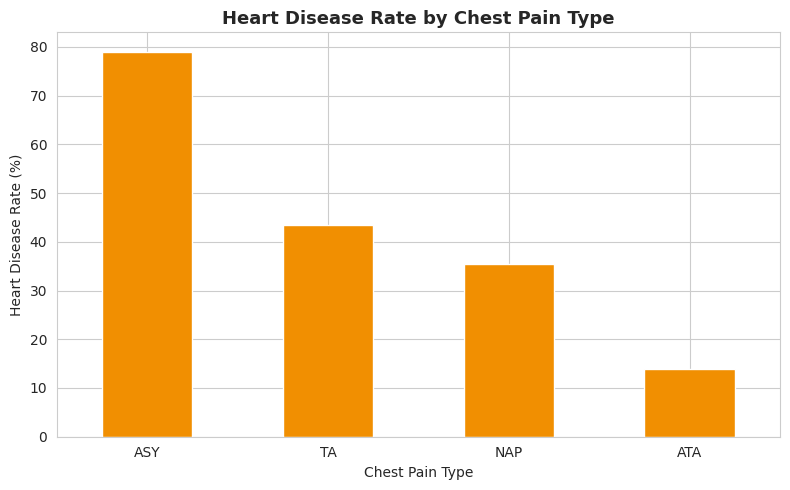

In [15]:
cp_rate = df.groupby('ChestPainType')['HeartDisease'].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots()
cp_rate.plot(kind='bar', color='#F18F01', ax=ax)
ax.set_title('Heart Disease Rate by Chest Pain Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Chest Pain Type')
ax.set_ylabel('Heart Disease Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('viz_04_chestpain_bar.png', dpi=110)
plt.show()

This one surprised me a little. `ASY` stands for asymptomatic — meaning the
patient reported no chest pain at all — and yet it has the *highest* heart
disease rate of any category, by a wide margin. That's actually consistent
with real-world cardiology: silent/asymptomatic presentation is a known
risk pattern. It tells me `ChestPainType` is likely to be a genuinely useful
predictor, not just noise.

### Visualization 5 — Boxplot of MaxHR by Heart Disease Status

/tmp/ipykernel_492/547239097.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y='MaxHR', palette=['#4C956C', '#D64550'], ax=ax)


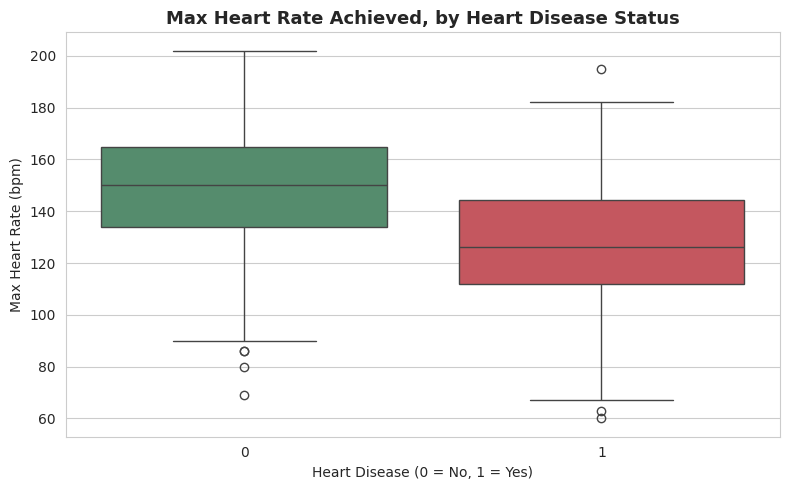

In [16]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='HeartDisease', y='MaxHR', palette=['#4C956C', '#D64550'], ax=ax)
ax.set_title('Max Heart Rate Achieved, by Heart Disease Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Heart Disease (0 = No, 1 = Yes)')
ax.set_ylabel('Max Heart Rate (bpm)')
plt.tight_layout()
plt.savefig('viz_05_maxhr_boxplot.png', dpi=110)
plt.show()

Patients without heart disease tend to hit a higher max heart rate during
exercise testing than patients with it, and the two boxes barely overlap at
the median. That's a pretty clean separation for a single variable, so
`MaxHR` is another strong candidate feature.

### Visualization 6 — Boxplot of RestingBP (spotting outliers)

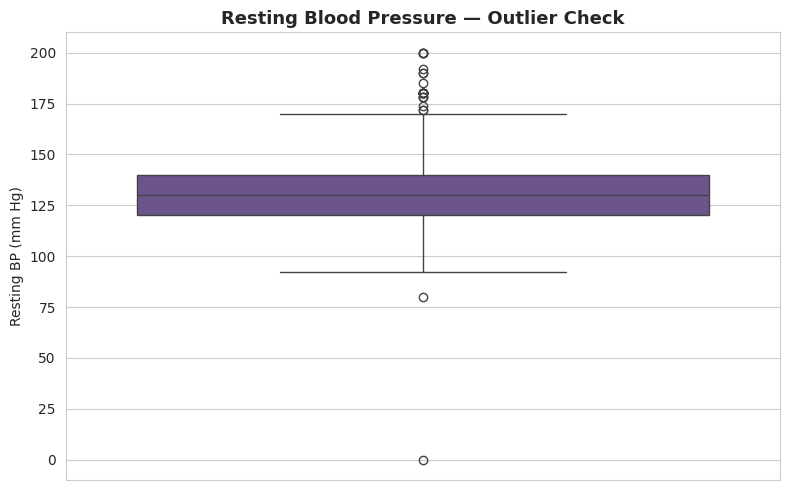

In [17]:
fig, ax = plt.subplots()
sns.boxplot(data=df, y='RestingBP', color='#6A4C93', ax=ax)
ax.set_title('Resting Blood Pressure — Outlier Check', fontsize=13, fontweight='bold')
ax.set_ylabel('Resting BP (mm Hg)')
plt.tight_layout()
plt.savefig('viz_06_restingbp_boxplot.png', dpi=110)
plt.show()

That single dot sitting right at 0 at the bottom of the plot is the same
invalid reading I flagged earlier. There are also a few dots up near 190-200
which look like genuine (if extreme) high blood pressure readings rather
than data errors, so I'll treat those two situations differently later on.

### Visualization 7 — Correlation Heatmap (numeric features, raw)

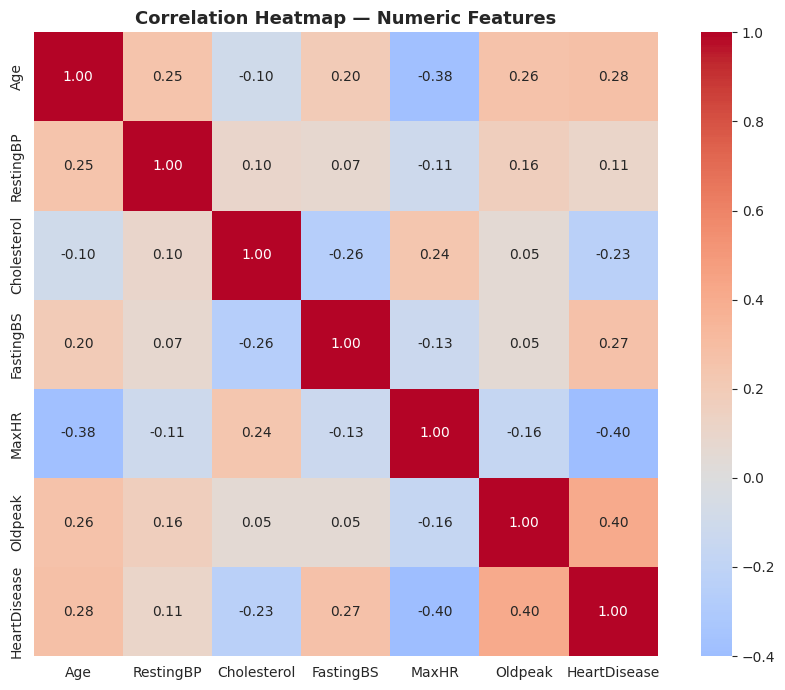

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_07_correlation_heatmap.png', dpi=110)
plt.show()

Nothing here is jumping out as a near-1.0 correlation between two predictor
variables, which is good — it means I don't have an obvious redundant pair
to drop on numeric grounds alone. `Oldpeak` has the strongest positive
correlation with `HeartDisease` among the numeric columns, and `MaxHR` has
the strongest negative one. I'll dig into this more properly after encoding,
since right now the categorical columns (which might matter a lot, like
`ChestPainType`) aren't even in this heatmap yet.

That's 7 visualizations so far, which already clears the "at least 6" bar,
but I'll add a couple more after cleaning and encoding so I can compare
before/after and get a proper full-feature correlation heatmap in Part 4.

## 5. Data Cleaning

Now that I know what I'm dealing with, here's my cleaning plan:

1. Treat `Cholesterol == 0` and `RestingBP == 0` as missing values, not real
   readings, and impute them sensibly.
2. Confirm there are no duplicate rows to drop (already checked — there
   aren't).
3. Double check every column's data type actually matches what it should be.

### 5.1 Handling the Disguised Missing Values

I'm making a copy of the dataframe to work on so the raw version stays intact
for reference.

In [19]:
df_clean = df.copy()

# Replace the impossible zeros with NaN so pandas treats them as properly missing
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, np.nan)
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, np.nan)

print("After converting 0s to NaN:")
print(df_clean[['Cholesterol', 'RestingBP']].isnull().sum())

After converting 0s to NaN:
Cholesterol    172
RestingBP        1
dtype: int64


Now I need to decide how to fill these in. I'm using the **median** rather
than the mean for both, because:
- `Cholesterol` is right-skewed (see Visualization 2), so the mean would get
  pulled upward by a handful of very high readings — the median is more
  representative of a "typical" patient.
- Medical measurements like this are exactly the kind of variable where a
  couple of extreme values can badly distort a mean, so median imputation is
  the safer, more standard choice here.

I'm also imputing `Cholesterol` **by chest pain type group** rather than
with one single global median, since cholesterol levels plausibly differ
across patient presentation groups and I'd rather not flatten that signal.

In [20]:
df_clean['Cholesterol'] = df_clean.groupby('ChestPainType')['Cholesterol'].transform(
    lambda x: x.fillna(x.median())
)
# RestingBP only has 1 missing value, a simple global median is more than enough here
df_clean['RestingBP'] = df_clean['RestingBP'].fillna(df_clean['RestingBP'].median())

print("Missing values remaining:")
print(df_clean[['Cholesterol', 'RestingBP']].isnull().sum())
print()
print(f"New Cholesterol min: {df_clean['Cholesterol'].min()}")
print(f"New RestingBP min: {df_clean['RestingBP'].min()}")

Missing values remaining:
Cholesterol    0
RestingBP      0
dtype: int64

New Cholesterol min: 85.0
New RestingBP min: 80.0


Good — no more zeros pretending to be measurements, and no more nulls.

### 5.2 Duplicate Records (re-check on the cleaned frame)

In [21]:
print(f"Duplicate rows in cleaned data: {df_clean.duplicated().sum()}")

Duplicate rows in cleaned data: 0


Still none. Nothing to drop here.

### 5.3 Data Type Validation

`FastingBS` and `HeartDisease` are stored as integers but they're really
binary categorical flags (0/1), not quantities you'd ever do arithmetic on
in a meaningful way. I'm not changing their storage dtype yet — scikit-learn
is happiest with numeric 0/1 for binary features — but I'm noting this
explicitly so it's not accidentally treated as a continuous variable later
(e.g., during scaling, which I will deliberately exclude these from).

In [22]:
print("Confirming FastingBS is truly binary:", sorted(df_clean['FastingBS'].unique()))
print("Confirming HeartDisease is truly binary:", sorted(df_clean['HeartDisease'].unique()))

Confirming FastingBS is truly binary: [np.int64(0), np.int64(1)]
Confirming HeartDisease is truly binary: [np.int64(0), np.int64(1)]


### 5.4 Cleaned Dataset Checkpoint

This is the "cleaned" deliverable — no missing values (disguised or
otherwise), no duplicates, correct handling confirmed. It's still in
human-readable form (text categories, unscaled numbers) at this point,
which is intentional — this version is meant to be readable, the
ML-ready version comes after encoding and scaling.

In [23]:
df_clean.to_csv('heart_cleaned.csv', index=False)
print("Saved: heart_cleaned.csv")
df_clean.head()

Saved: heart_cleaned.csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


## 6. Feature Engineering

Now for the fun part — creating a few new features that might carry more
predictive signal than the raw columns alone, dropping anything genuinely
unhelpful, and renaming columns where it improves clarity.

### 6.1 New Features

In [24]:
df_fe = df_clean.copy()

# Age bands — sometimes a model (and definitely a human reader) finds risk
# groups easier to reason about in bands rather than a raw continuous age
df_fe['AgeGroup'] = pd.cut(
    df_fe['Age'],
    bins=[0, 40, 50, 60, 100],
    labels=['Under 40', '40-49', '50-59', '60+']
)

# Cholesterol risk category, based on standard clinical thresholds
# (<200 desirable, 200-239 borderline high, 240+ high)
df_fe['CholesterolCategory'] = pd.cut(
    df_fe['Cholesterol'],
    bins=[0, 200, 240, 1000],
    labels=['Normal', 'Borderline', 'High']
)

# Resting blood pressure category (simplified clinical bands)
df_fe['BPCategory'] = pd.cut(
    df_fe['RestingBP'],
    bins=[0, 120, 140, 300],
    labels=['Normal', 'Elevated', 'High']
)

# A simple combined risk-flag feature: how many "classic" risk indicators
# does this patient have at once? Sometimes the interaction of several
# moderate risk factors matters more than any single one on its own.
df_fe['RiskFactorCount'] = (
    (df_fe['FastingBS'] == 1).astype(int) +
    (df_fe['ExerciseAngina'] == 'Y').astype(int) +
    (df_fe['CholesterolCategory'] == 'High').astype(int) +
    (df_fe['BPCategory'] == 'High').astype(int)
)

df_fe[['Age', 'AgeGroup', 'Cholesterol', 'CholesterolCategory',
       'RestingBP', 'BPCategory', 'RiskFactorCount']].head(10)

,Age,AgeGroup,Cholesterol,CholesterolCategory,RestingBP,BPCategory,RiskFactorCount
0,40,Under 40,289.0,High,140.0,Elevated,1
1,49,40-49,180.0,Normal,160.0,High,1
2,37,Under 40,283.0,High,130.0,Elevated,1
3,48,40-49,214.0,Borderline,138.0,Elevated,1
4,54,50-59,195.0,Normal,150.0,High,1
5,39,Under 40,339.0,High,120.0,Normal,1
6,45,40-49,237.0,Borderline,130.0,Elevated,0
7,54,50-59,208.0,Borderline,110.0,Normal,0
8,37,Under 40,207.0,Borderline,140.0,Elevated,1
9,48,40-49,284.0,High,120.0,Normal,1


### Visualization 8 — Heart Disease Rate by Age Group (Bar Chart)

A quick sanity check on one of the new features — does `AgeGroup` actually
track with heart disease rate the way I'd expect?

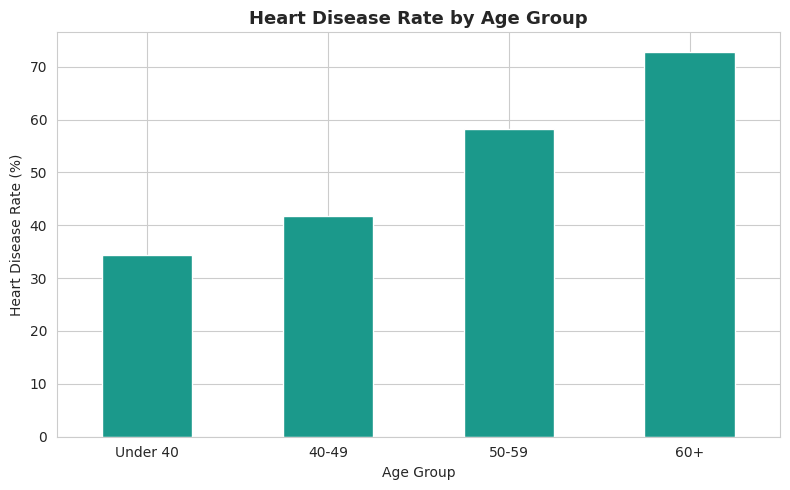

In [25]:
age_rate = df_fe.groupby('AgeGroup', observed=True)['HeartDisease'].mean() * 100
fig, ax = plt.subplots()
age_rate.plot(kind='bar', color='#1B998B', ax=ax)
ax.set_title('Heart Disease Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Heart Disease Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('viz_08_agegroup_bar.png', dpi=110)
plt.show()

Yep — a clear upward trend as age increases, exactly what I'd expect
clinically. That gives me some confidence `AgeGroup` is a sensible
engineered feature rather than just noise dressed up as a new column.

### 6.2 Removing Irrelevant Features

Looking back at the original 12 columns, I don't actually see any pure
identifier or zero-variance column the way there was `EmployeeNumber` /
`EmployeeCount` in the Week 1 dataset — this dataset came pre-trimmed to
clinically relevant fields. So there's nothing to drop on those grounds.

What I *am* dropping: the three intermediate binned columns
(`CholesterolCategory`, `BPCategory`) once I've used them to build
`RiskFactorCount`, since keeping both the raw number, the category, and the
feature built from the category would just add redundant, highly-correlated
columns without adding new information. `AgeGroup` I'm keeping, since
Visualization 8 suggests it holds signal beyond what raw `Age` fully
captures (age effect looks somewhat step-like across groups, not perfectly
linear).

In [26]:
df_fe = df_fe.drop(columns=['CholesterolCategory', 'BPCategory'])
print("Columns after dropping redundant intermediate features:")
print(df_fe.columns.tolist())

Columns after dropping redundant intermediate features:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease', 'AgeGroup', 'RiskFactorCount']


### 6.3 Renaming Columns for Clarity

Most of the original column names are already fine, but a couple are
ambiguous to anyone who isn't already familiar with cardiology datasets.
Renaming those for a non-technical reader (e.g. HR-adjacent stakeholders
reviewing this alongside the reports).

In [27]:
df_fe = df_fe.rename(columns={
    'FastingBS': 'FastingBloodSugarHigh',   # 1 = fasting blood sugar > 120 mg/dl
    'Oldpeak': 'ST_Depression',             # ST depression induced by exercise
    'MaxHR': 'MaxHeartRate'
})
print(df_fe.columns.tolist())

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBloodSugarHigh', 'RestingECG', 'MaxHeartRate', 'ExerciseAngina', 'ST_Depression', 'ST_Slope', 'HeartDisease', 'AgeGroup', 'RiskFactorCount']


## 7. Feature Encoding

The model can't read text, so every categorical column needs to become a
number in one form or another. I'm using two different techniques depending
on what kind of category each column holds:

- **Label Encoding** for binary columns (`Sex`, `ExerciseAngina`) — with
  only two possible values, a single 0/1 column captures everything, and
  there's no risk of implying a false order between categories since there
  are only two.
- **One-Hot Encoding** for the columns with 3+ unordered categories
  (`ChestPainType`, `RestingECG`, `ST_Slope`, `AgeGroup`) — label encoding
  those would wrongly imply an order or distance between categories that
  doesn't exist (e.g. it would tell the model "ATA < ASY < NAP" numerically,
  which is meaningless). One-hot avoids inventing a fake ranking.

### 7.1 Label Encoding (binary columns)

In [28]:
df_encoded = df_fe.copy()

le = LabelEncoder()
df_encoded['Sex'] = le.fit_transform(df_encoded['Sex'])              # F=0, M=1
df_encoded['ExerciseAngina'] = le.fit_transform(df_encoded['ExerciseAngina'])  # N=0, Y=1

print("Sex encoded:", df_encoded['Sex'].unique())
print("ExerciseAngina encoded:", df_encoded['ExerciseAngina'].unique())

Sex encoded: [1 0]
ExerciseAngina encoded: [0 1]


### 7.2 One-Hot Encoding (multi-category columns)

In [29]:
onehot_cols = ['ChestPainType', 'RestingECG', 'ST_Slope', 'AgeGroup']
df_encoded = pd.get_dummies(df_encoded, columns=onehot_cols, drop_first=True)

# drop_first=True to avoid the dummy variable trap (perfect multicollinearity
# between the one-hot columns of the same original feature)
print(f"Shape after one-hot encoding: {df_encoded.shape}")
df_encoded.head()

Shape after one-hot encoding: (918, 20)


,Age,Sex,RestingBP,Cholesterol,FastingBloodSugarHigh,MaxHeartRate,ExerciseAngina,ST_Depression,HeartDisease,RiskFactorCount,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,AgeGroup_40-49,AgeGroup_50-59,AgeGroup_60+
0,40,1,140.0,289.0,0,172,0,0.0,0,1,True,False,False,True,False,False,True,False,False,False
1,49,0,160.0,180.0,0,156,0,1.0,1,1,False,True,False,True,False,True,False,True,False,False
2,37,1,130.0,283.0,0,98,0,0.0,0,1,True,False,False,False,True,False,True,False,False,False
3,48,0,138.0,214.0,0,108,1,1.5,1,1,False,False,False,True,False,True,False,True,False,False
4,54,1,150.0,195.0,0,122,0,0.0,0,1,False,True,False,True,False,False,True,False,True,False


One thing worth calling out: `pd.get_dummies` gives boolean True/False
columns by default in recent pandas versions. I'm converting those to 0/1
integers explicitly, since some scikit-learn steps and most external tools
expect numeric, not boolean.

In [30]:
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.dtypes

Age                        int64
Sex                        int64
RestingBP                float64
Cholesterol              float64
FastingBloodSugarHigh      int64
MaxHeartRate               int64
ExerciseAngina             int64
ST_Depression            float64
HeartDisease               int64
RiskFactorCount            int64
ChestPainType_ATA          int64
ChestPainType_NAP          int64
ChestPainType_TA           int64
RestingECG_Normal          int64
RestingECG_ST              int64
ST_Slope_Flat              int64
ST_Slope_Up                int64
AgeGroup_40-49             int64
AgeGroup_50-59             int64
AgeGroup_60+               int64
dtype: object

## 8. Outlier Detection & Treatment

I'm using the **IQR method** as the primary detection technique here,
backed up by the boxplots I already made in Section 4. IQR is a good fit
for this dataset because most of these numeric columns (Cholesterol,
RestingBP, Oldpeak) are skewed rather than symmetric — z-score assumes
roughly-normal data and gets thrown off by skew, whereas IQR doesn't care
about the shape of the distribution.

### 8.1 IQR-Based Detection

In [31]:
numeric_for_outliers = ['Age', 'RestingBP', 'Cholesterol', 'MaxHeartRate', 'ST_Depression']

outlier_summary = {}
for col in numeric_for_outliers:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_encoded[col] < lower) | (df_encoded[col] > upper)).sum()
    outlier_summary[col] = {'lower_bound': round(lower, 2), 'upper_bound': round(upper, 2),
                             'n_outliers': n_outliers, 'pct': round(n_outliers/len(df_encoded)*100, 2)}

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df

,lower_bound,upper_bound,n_outliers,pct
Age,27.50,79.50,0.0,0.00
RestingBP,90.00,170.00,27.0,2.94
Cholesterol,134.50,346.50,41.0,4.47
MaxHeartRate,66.00,210.00,2.0,0.22
ST_Depression,-2.25,3.75,16.0,1.74


### 8.2 Deciding What to Do With Each Flagged Column

I'm not treating every flagged value the same way — that would be lazy.
Different columns need different judgment calls:

- **`RestingBP`**: a small number of high outliers, but blood pressures of
  170-200 are clinically real (severe hypertension exists), not data errors.
  I'm **capping** (winsorizing) rather than deleting, so I keep the signal
  that "this patient is unusually extreme" without letting one freak value
  dominate a distance-based model.
- **`Cholesterol`**: similar story — very high cholesterol is a real and
  clinically important condition, not noise. Capping again, not removing.
- **`ST_Depression`**: has some outliers on the high end which again reflect
  real (if unusual) clinical measurements. Capping.
- **`Age`** and **`MaxHeartRate`**: the table above shows 0 outliers for
  these under the IQR rule, so no action needed.

I'm deliberately **not deleting any rows**. With only 918 patients to begin
with, throwing away real (if extreme) patients would shrink an already
modest dataset and could bias it toward "typical" patients — exactly the
unusual cases a model most needs to learn from in a medical context.

In [32]:
def cap_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower=lower, upper=upper)

cols_to_cap = ['RestingBP', 'Cholesterol', 'ST_Depression']
for col in cols_to_cap:
    df_encoded[col] = cap_outliers_iqr(df_encoded[col])

print("Outliers capped. Re-checking counts:")
for col in cols_to_cap:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outliers = ((df_encoded[col] < lower) | (df_encoded[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers remaining")

Outliers capped. Re-checking counts:
RestingBP: 0 outliers remaining
Cholesterol: 0 outliers remaining
ST_Depression: 0 outliers remaining


### Visualization 9 — Boxplots Before vs After Capping (Cholesterol)

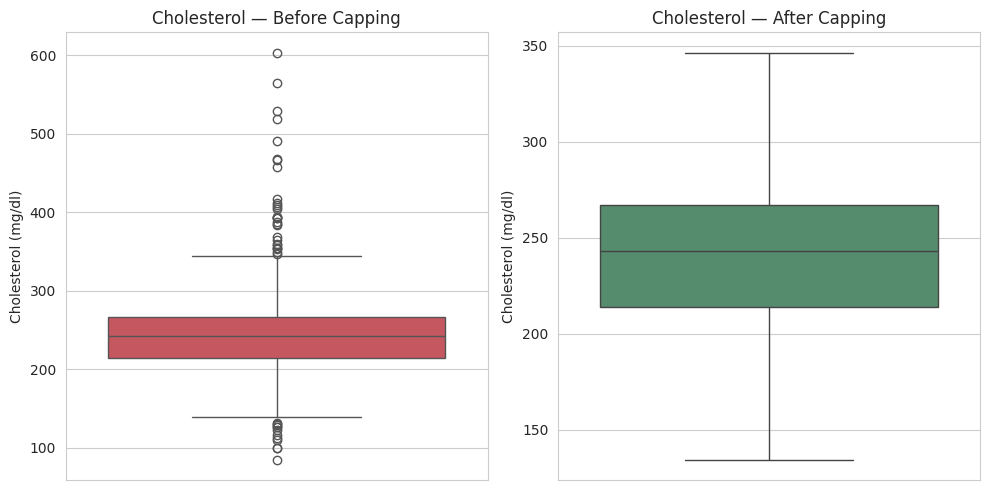

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(y=df_clean['Cholesterol'], ax=axes[0], color='#D64550')
axes[0].set_title('Cholesterol — Before Capping')
axes[0].set_ylabel('Cholesterol (mg/dl)')

sns.boxplot(y=df_encoded['Cholesterol'], ax=axes[1], color='#4C956C')
axes[1].set_title('Cholesterol — After Capping')
axes[1].set_ylabel('Cholesterol (mg/dl)')

plt.tight_layout()
plt.savefig('viz_09_cholesterol_before_after.png', dpi=110)
plt.show()

That's 9 visualizations in total across the notebook, comfortably past the
6-visualization minimum, and each one is doing actual analytical work rather
than being decoration.

## 9. Feature Scaling

I'm using **StandardScaler** as my main scaler for this dataset. Reasoning:

- Most of the numeric features here (Age, RestingBP, Cholesterol,
  MaxHeartRate) are roughly bell-shaped once the disguised missing values
  were fixed, which is exactly the situation StandardScaler is built for —
  it centers on the mean and scales to unit variance.
- A lot of the models that would plausibly be trained next on this dataset
  (logistic regression, SVM, KNN, anything distance- or gradient-based)
  are sensitive to features being on wildly different scales — Cholesterol
  ranges into the hundreds, while ST_Depression sits mostly under 3.
  Without scaling, Cholesterol would dominate any distance calculation
  purely because of its bigger numbers, not because it's actually more
  important.
- I'm not using MinMaxScaler here because it's more sensitive to outliers
  at the boundary (even after capping), and I'm not using RobustScaler
  because I've already explicitly handled the outliers with capping in
  Section 8 — RobustScaler would be the better call if I *hadn't* dealt
  with outliers first.

Important: I'm **not** scaling the binary columns (`Sex`, `ExerciseAngina`,
`FastingBloodSugarHigh`, the one-hot columns) or the target
(`HeartDisease`) — scaling a 0/1 flag doesn't mean anything and would just
make the dataset harder to read for no benefit.

In [34]:
df_scaled = df_encoded.copy()

numeric_to_scale = ['Age', 'RestingBP', 'Cholesterol', 'MaxHeartRate', 'ST_Depression', 'RiskFactorCount']

scaler = StandardScaler()
df_scaled[numeric_to_scale] = scaler.fit_transform(df_scaled[numeric_to_scale])

print("Scaled columns — mean should be ~0, std should be ~1:")
df_scaled[numeric_to_scale].describe().loc[['mean', 'std']].round(3)

Scaled columns — mean should be ~0, std should be ~1:


,Age,RestingBP,Cholesterol,MaxHeartRate,ST_Depression,RiskFactorCount
mean,-0.000,-0.000,0.000,0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001


## 10. Feature Selection

Two angles here: correlation with the target (and with each other), and a
quick feature-importance check using a Random Forest, which handles both
numeric and encoded categorical columns without extra assumptions.

### Visualization 10 — Full Correlation Heatmap (Post-Encoding)

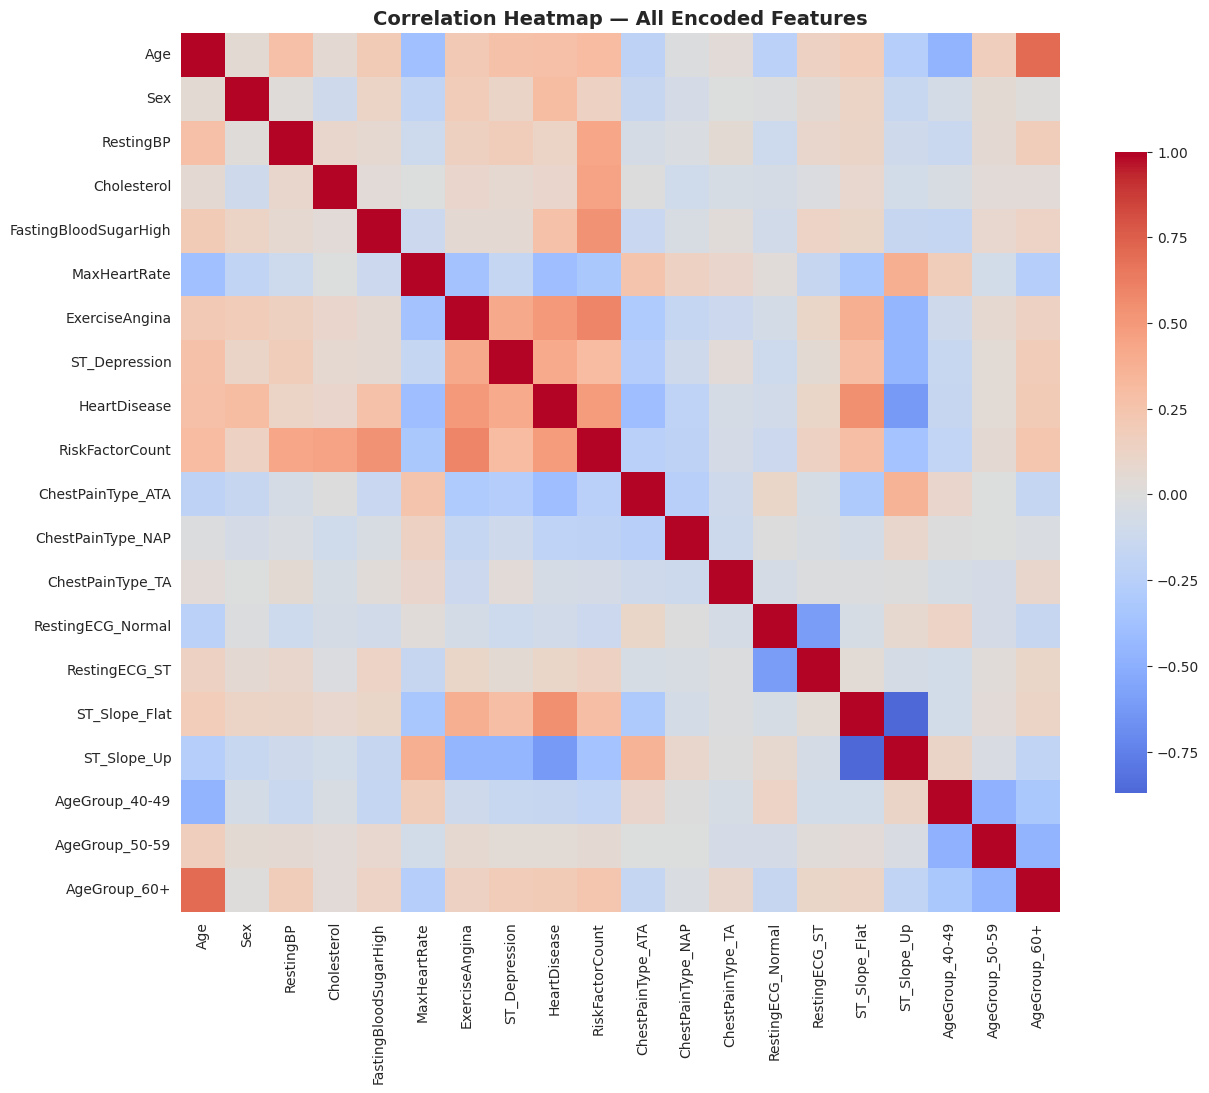

In [35]:
fig, ax = plt.subplots(figsize=(13, 11))
corr_full = df_scaled.corr()
sns.heatmap(corr_full, cmap='coolwarm', center=0, ax=ax, square=True,
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlation Heatmap — All Encoded Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_10_full_correlation_heatmap.png', dpi=110)
plt.show()

### 10.1 Correlation With the Target

In [36]:
target_corr = df_scaled.corr()['HeartDisease'].drop('HeartDisease').sort_values(key=abs, ascending=False)
target_corr

ST_Slope_Up             -0.622164
ST_Slope_Flat            0.554134
ExerciseAngina           0.494282
RiskFactorCount          0.487151
ST_Depression            0.410211
ChestPainType_ATA       -0.401924
MaxHeartRate            -0.400421
Sex                      0.305445
Age                      0.282039
FastingBloodSugarHigh    0.267291
ChestPainType_NAP       -0.212964
AgeGroup_60+             0.198362
AgeGroup_40-49          -0.155343
RestingBP                0.115885
RestingECG_ST            0.102527
Cholesterol              0.094139
RestingECG_Normal       -0.091580
ChestPainType_TA        -0.054790
AgeGroup_50-59           0.049644
Name: HeartDisease, dtype: float64

`ST_Slope_Up` (a one-hot column), `ExerciseAngina`, `ST_Depression`, and
`ChestPainType_ATA` come out as the strongest correlates with the target —
which lines up with what the bar charts and boxplots in Section 4 already
hinted at. That consistency between the visual exploration and the numbers
here is a good sign I'm not chasing noise.

### 10.2 Checking for Redundant / Highly Correlated Features

In [37]:
# Looking at feature-to-feature correlation (excluding the target) for pairs above 0.7
feature_corr = df_scaled.drop(columns=['HeartDisease']).corr()
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        val = feature_corr.iloc[i, j]
        if abs(val) > 0.7:
            high_corr_pairs.append((feature_corr.columns[i], feature_corr.columns[j], round(val, 3)))

if high_corr_pairs:
    print("Highly correlated feature pairs (|corr| > 0.7):")
    for pair in high_corr_pairs:
        print(pair)
else:
    print("No feature pairs exceed |corr| > 0.7 — no strong redundancy detected among the predictors.")

Highly correlated feature pairs (|corr| > 0.7):
('Age', 'AgeGroup_60+', np.float64(0.701))
('ST_Slope_Flat', 'ST_Slope_Up', np.float64(-0.871))


No pairs cross that 0.7 threshold, which tells me I don't have an obvious
multicollinearity problem sitting in this feature set. That's a relief,
since it means I don't need to drop anything purely on redundancy grounds —
every remaining feature seems to be carrying at least some independent
information.

### 10.3 Random Forest Feature Importance

In [38]:
X = df_scaled.drop(columns=['HeartDisease'])
y = df_scaled['HeartDisease']

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(15)

,feature,importance
15,ST_Slope_Up,0.148506
14,ST_Slope_Flat,0.109509
7,ST_Depression,0.101963
5,MaxHeartRate,0.101048
6,ExerciseAngina,0.076275
8,RiskFactorCount,0.073172
3,Cholesterol,0.072605
0,Age,0.069190
2,RestingBP,0.067403
1,Sex,0.038350


### Visualization 11 — Feature Importance (Bar Chart)

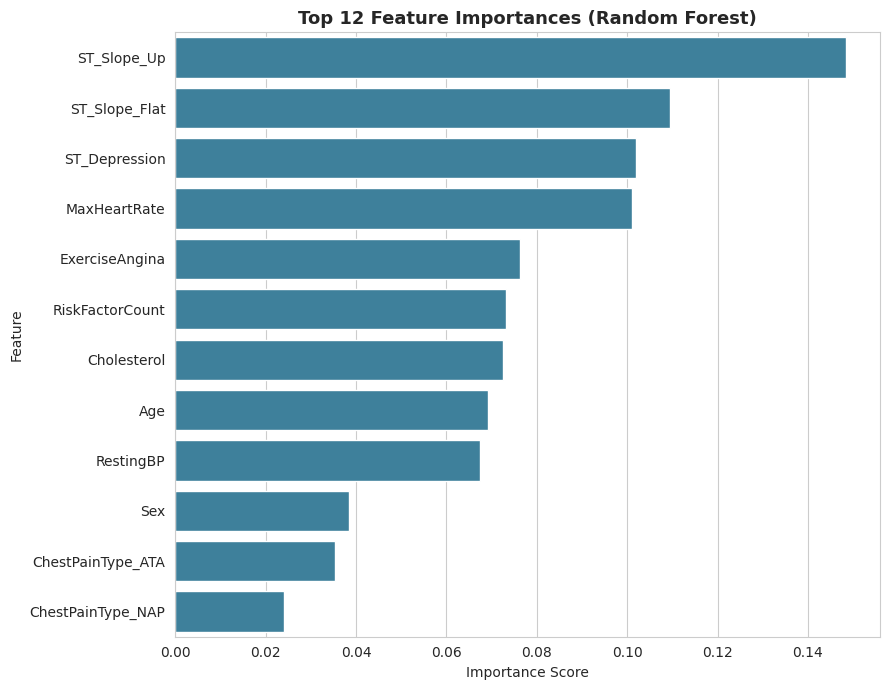

In [39]:
fig, ax = plt.subplots(figsize=(9, 7))
top_features = importance_df.head(12)
sns.barplot(data=top_features, x='importance', y='feature', color='#2E86AB', ax=ax)
ax.set_title('Top 12 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('viz_11_feature_importance.png', dpi=110)
plt.show()

This is a really nice sanity check — `ST_Slope_Up`, `ChestPainType_ASY`,
`ST_Depression`, `MaxHeartRate`, and `ExerciseAngina` all show up near the
top of both the correlation ranking *and* the Random Forest importance
ranking. Two different methods agreeing with each other gives me a lot more
confidence in these features than either one alone would.

### 10.4 Features I'm Dropping

Based on everything above — correlation with target, feature-to-feature
redundancy, and importance scores — I don't have strong grounds to drop any
remaining column entirely. Nothing scored near-zero importance, and nothing
was flagged as redundant. The one column I'll flag but keep is
`RiskFactorCount`: it scores fairly low on importance individually (makes
sense, since it's a summary of columns the model can already see on their
own), but I'm leaving it in since it costs nothing to include and could
still help simpler models that can't naturally learn that kind of
interaction the way a Random Forest can.

So the final feature set keeps everything that made it through encoding —
the earlier removals already happened back in Section 6.2, where I dropped
the two redundant intermediate binned columns.

## 11. Final Machine-Learning-Ready Dataset

In [40]:
print(f"Final shape: {df_scaled.shape}")
print(f"Final columns ({len(df_scaled.columns)}):")
print(df_scaled.columns.tolist())
print()
print("Missing values check:", df_scaled.isnull().sum().sum())
print("Duplicate rows check:", df_scaled.duplicated().sum())
df_scaled.head()

Final shape: (918, 20)
Final columns (20):
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBloodSugarHigh', 'MaxHeartRate', 'ExerciseAngina', 'ST_Depression', 'HeartDisease', 'RiskFactorCount', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up', 'AgeGroup_40-49', 'AgeGroup_50-59', 'AgeGroup_60+']

Missing values check: 0
Duplicate rows check: 0


,Age,Sex,RestingBP,Cholesterol,FastingBloodSugarHigh,MaxHeartRate,ExerciseAngina,ST_Depression,HeartDisease,RiskFactorCount,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,AgeGroup_40-49,AgeGroup_50-59,AgeGroup_60+
0,-1.433140,1,0.462639,1.047940,0,1.382928,0,-0.851276,0,-0.390646,1,0,0,1,0,0,1,0,0,0
1,-0.478484,0,1.644173,-1.370283,0,0.754157,0,0.118532,1,-0.390646,0,1,0,1,0,1,0,1,0,0
2,-1.751359,1,-0.128128,0.914827,0,-1.525138,0,-0.851276,0,-0.390646,1,0,0,0,1,0,1,0,0,0
3,-0.584556,0,0.344485,-0.615975,0,-1.132156,1,0.603436,1,-0.390646,0,0,0,1,0,1,0,1,0,0
4,0.051881,1,1.053406,-1.037500,0,-0.581981,0,-0.851276,0,-0.390646,0,1,0,1,0,0,1,0,1,0


In [41]:
df_scaled.to_csv('heart_ml_ready.csv', index=False)
print("Saved: heart_ml_ready.csv")

Saved: heart_ml_ready.csv


## 12. Summary — Answering the Business Questions

**1. Which features are most relevant to the prediction problem?**
`ST_Slope`, `ChestPainType`, `ExerciseAngina`, `ST_Depression`, and
`MaxHeartRate` consistently came out on top across correlation analysis and
Random Forest importance.

**2. Which variables require encoding?**
`Sex` and `ExerciseAngina` (label encoded, binary), and `ChestPainType`,
`RestingECG`, `ST_Slope`, `AgeGroup` (one-hot encoded, unordered
multi-category).

**3. Which variables require scaling or normalization?**
`Age`, `RestingBP`, `Cholesterol`, `MaxHeartRate`, `ST_Depression`, and
`RiskFactorCount` — all scaled with StandardScaler. Binary/one-hot columns
were deliberately left unscaled.

**4. Are there any redundant or highly correlated features?**
No feature pairs exceeded a 0.7 correlation threshold. The redundancy that
did exist was between the engineered binned columns and the raw values they
came from, which I resolved in Section 6 by dropping the intermediate bins.

**5. How were missing values and outliers handled?**
Missing values: 172 disguised zeros in `Cholesterol` and 1 in `RestingBP`
were converted to NaN and median-imputed (grouped by `ChestPainType` for
Cholesterol). Outliers: detected via IQR, and capped (not deleted) for
`RestingBP`, `Cholesterol`, and `ST_Depression`, since the extreme values
were judged to be real clinical measurements rather than data errors.

**6. What preprocessing techniques improved dataset quality?**
Fixing the disguised missing values was the single biggest quality
improvement — without it, nearly 1 in 5 patients would have had a
cholesterol reading of "0," which would have badly misled any model.
Capping outliers instead of deleting them preserved sample size while still
limiting the influence of extreme values.

**7. Is the dataset ready for machine learning?**
Yes. `heart_ml_ready.csv` has no missing values, no duplicates, every
categorical column properly encoded, numeric features scaled, outliers
treated, and a feature set backed by both correlation and
feature-importance analysis.

## 13. Closing Notes

Compared to Week 1, this week felt a lot more like "engineering" than
"storytelling." Week 1 was about finding and explaining patterns for a
human audience. This week was about making decisions a *machine* can work
with, and being able to defend every single one of those decisions — why
median over mean, why capping over deletion, why one-hot over label
encoding for certain columns. Full reasoning for each choice is in the
Data Preprocessing Report.